# **Sandbox Notebook for Testing Hyperparameters and Specific Runs of Simulation**
Using HG approach.

In [17]:
# general imports
import numpy as np
import matplotlib.pyplot as plt
# ml imports
import torch
import torch.nn.functional as F
from tqdm import tqdm

# import module
from nlse import *

In [18]:
# define simulation parameters used in inverse design
Lz = 1e-3               # Propagation distance in km (1cm = 1e-5)
Nz = 100               # Number of steps in z
dz = Lz / Nz            # Step size in z
Lt = 3                  # Temporal window size
Nt = 2048               # Number of temporal points
dt = Lt / Nt
N_modes = 100

# define medium parameters
beta2_j = -10           # anomalous GVD region
beta2_k = 0           # anomalous GVD region
gamma_j = 1
gamma_k = 0

# define pulse parameters
tau = 0.1               # temporal width of the pulse = 100 fs - also, characteristic time of Hermite-Gauss basis used in simulation

# flags
USE_HARD_CONSTRAINT = False

# define HG basis
t = torch.linspace(-Lt/2, Lt/2, Nt)
hg_basis = get_hg_basis(N_modes, t, tau)

# convenience constants
eps = 1e-10

Precomputed 100 HG basis functions on grid of 2048 points on device cpu


In [19]:
def strong_soliton(t, beta2_k, gamma_k, tau):
    """Create the strong pulse (A_k) based on the soliton parameters."""
    # calculate secondary parameters
    if gamma_k > eps:
        a_2_squared = -beta2_k / (gamma_k * tau**2)
        a_2 = np.sqrt(a_2_squared)
    else: # SPM and Dispersion Off (Use Baseline Values)
        a_2_squared = -(-10) / ((1) * tau**2) 
        a_2 = np.sqrt(a_2_squared)
    
    # Define strong pulse waveform
    Ain_k = a_2 * torch.cosh(t / tau)**(-1)
    
    return Ain_k

def weak_soliton(t, beta2_k, beta2_j, gamma_j, gamma_k, tau, amplitude_ratio=100.0):
    """Create the weak pulse (A_j) based on the soliton parameters."""
    # calculate secondary parameters
    if gamma_k > eps:
        a_2_squared = -beta2_k / (gamma_k * tau**2)
        a_2 = np.sqrt(a_2_squared)
        # For the weak pulse A_1 (soliton-like):
        p = 0.5 * (-1 + np.sqrt(1 + 16 * beta2_k * gamma_j / (beta2_j * gamma_k)))
    else: # SPM and Dispersion Off (Use Baseline Values)
        a_2_squared = -(-10) / ((1) * tau**2) 
        a_2 = np.sqrt(a_2_squared)
        # For the weak pulse A_1 (soliton-like):
        p = 0.5 * (-1 + np.sqrt(1 + 16 * (-10) * gamma_j / (beta2_j * (1))))
    a_1 = a_2 / amplitude_ratio
    print(a_1)
    
    
    
    # Define weak pulse waveform
    Ain_j = a_1 * (torch.cosh(t / tau)**(-1))**p
    
    return Ain_j

In [20]:
weak = weak_soliton(t, beta2_k, beta2_j, gamma_j, gamma_k, tau, amplitude_ratio=100)

0.3162277660168379


## **Test 1: Large Amplitudes and $dz$ selection**
Start with strong and weak pulse pair with amplitude ratio of 100.

In [21]:
# Keep weak pulse constant (original, not scaled)
A_weak = weak_soliton(t, beta2_k, beta2_j, gamma_j, gamma_k, tau, amplitude_ratio=100)

# Initialize strong pulse (will be scaled by amplitude_ratio)
A_strong = strong_soliton(t, beta2_k, gamma_k, tau)
theta_strong = time_to_hg(A_strong, hg_basis, dt) # parametrization for strong pulse
base_scale_factor = torch.norm(theta_strong)

0.3162277660168379


See parametrization of pulse

Scale it up by $\alpha$

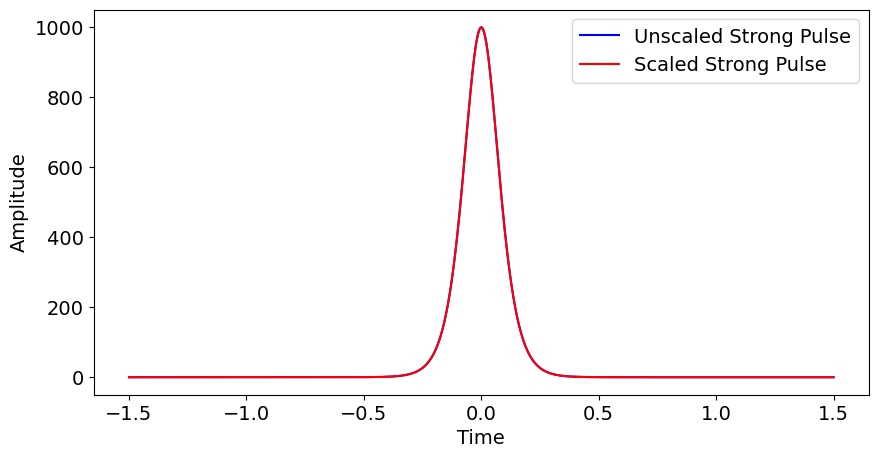

In [22]:
alpha = 1
theta_scaled = theta_strong * alpha
A_strong_scaled = hg_to_time(theta_scaled, hg_basis)

# plot the scaled and unscaled strong pulses
plt.figure(figsize=(10, 5))
plt.plot(t, np.abs(A_strong)**2, label='Unscaled Strong Pulse', color='blue')
plt.plot(t, np.abs(A_strong_scaled)**2, label='Scaled Strong Pulse', color='red')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()

Simulate evolution of scaled pulse, set $N_z$ to specific value

*We know that values of $\alpha=1$ and $N_z=100$ work and since the main acting nonlinear term is $\propto |A^2|dz$ we expect the necessary $N_z$ to scale quadratically with $alpha$, that is $N_z \propto \alpha^2$*


In [23]:
Nz = 5000 #Nz * alpha**2
dz = Lz / Nz
print("Instead of original Nz = 100, we use Nz =", Nz)
A_j_evolution, A_k_evolution = split_step_fourier_xpm(A_weak, A_strong_scaled, dz, Nz, beta2_j, beta2_k, gamma_j, gamma_k, Lt)

Instead of original Nz = 100, we use Nz = 5000


Analyze results

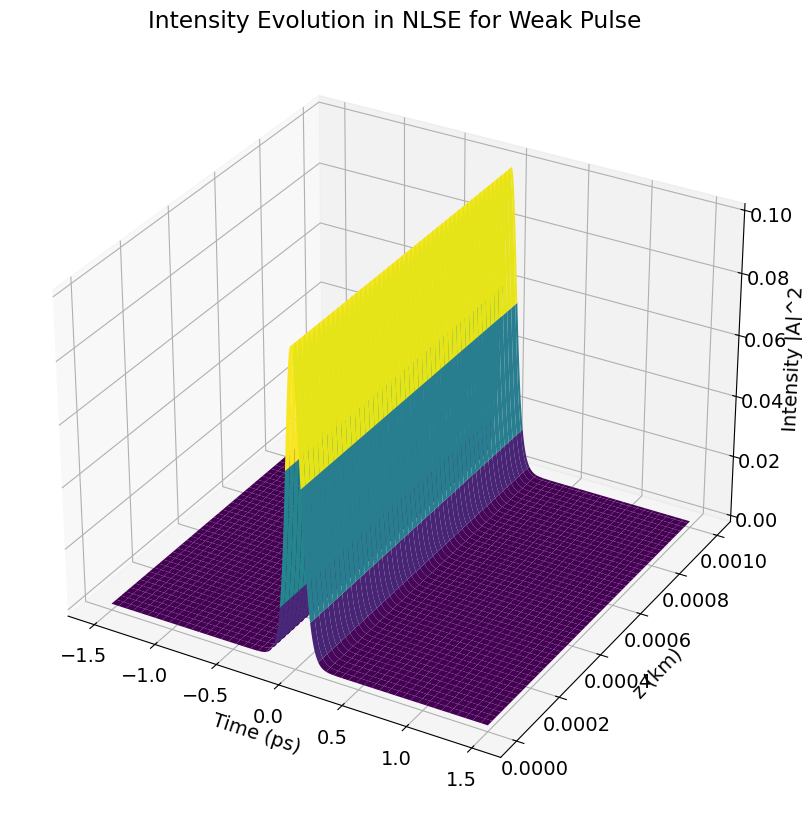

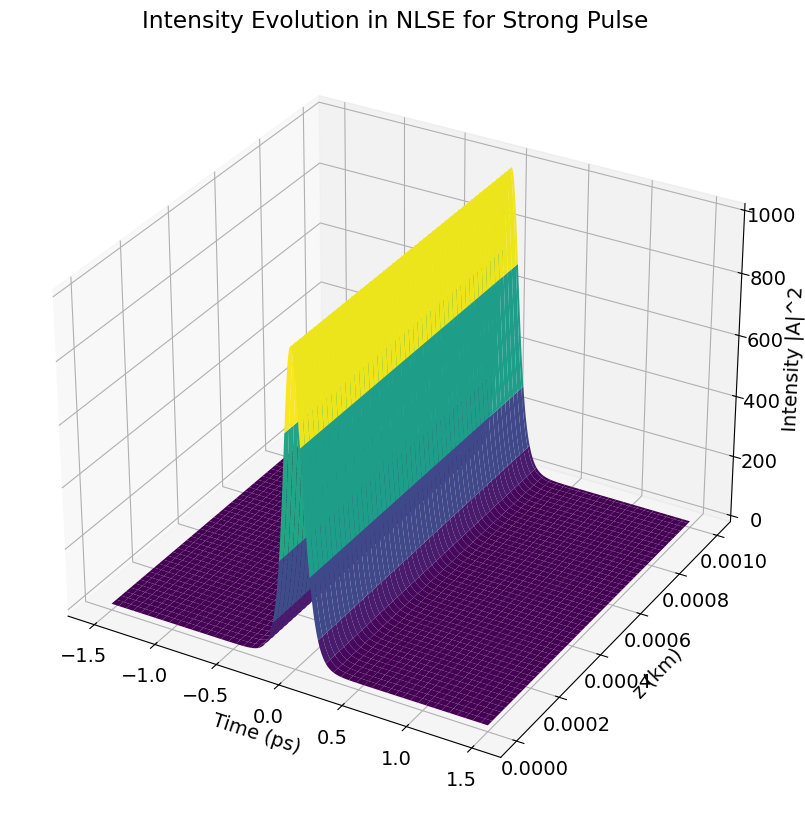

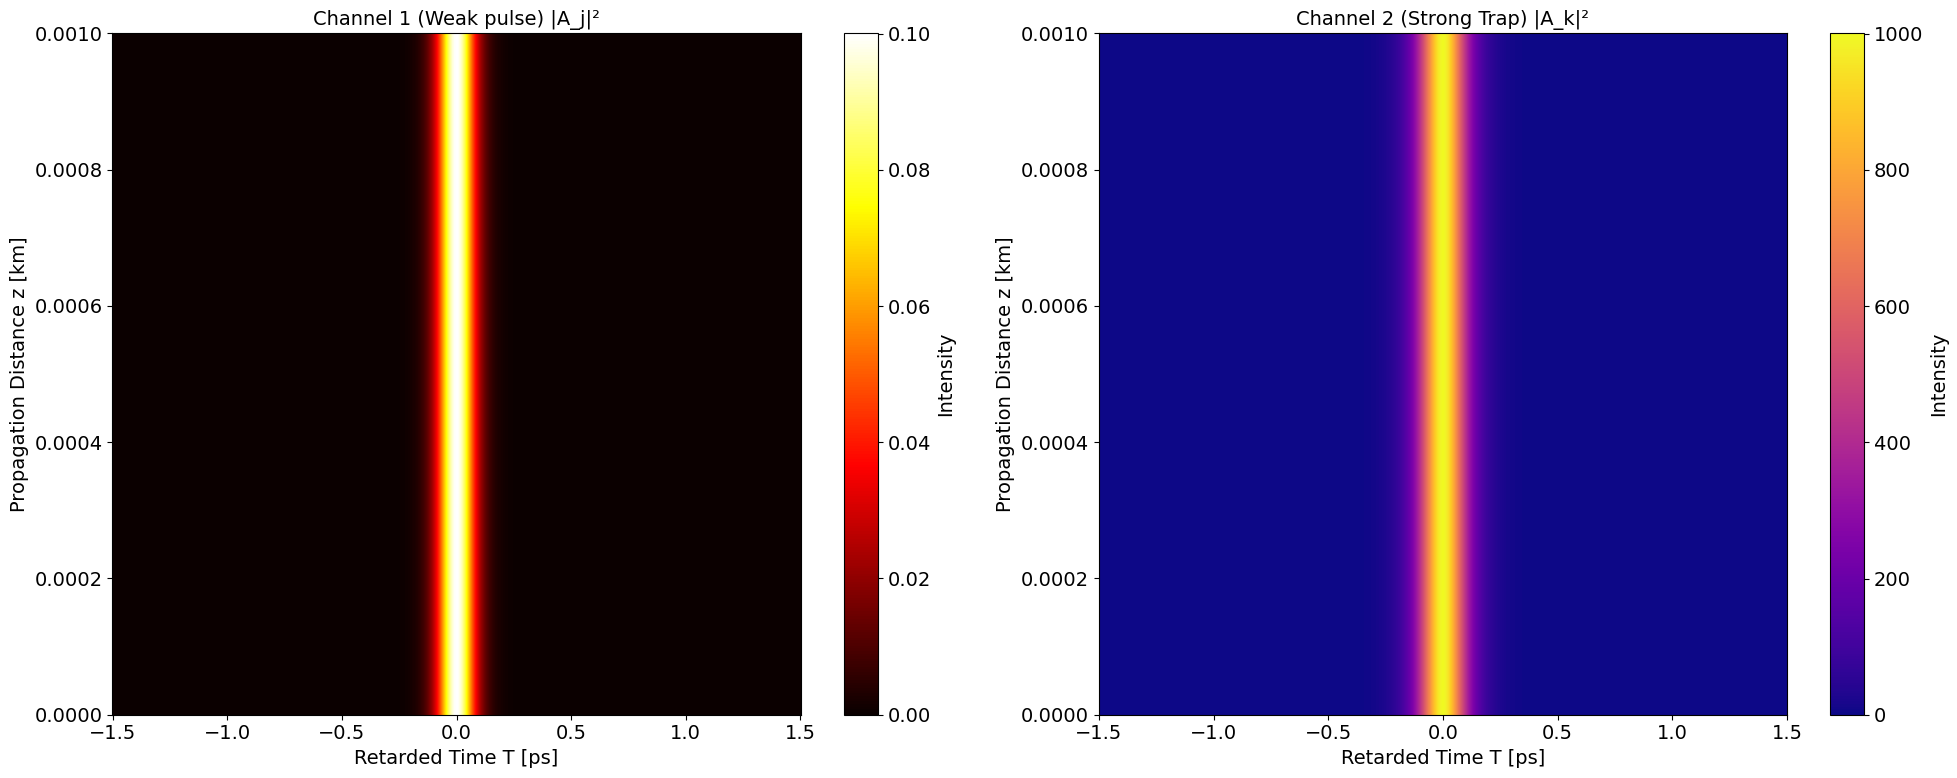

In [24]:
plot_intensity_evolution(A_j_evolution, t, Lz, Nz, wave_name='Weak Pulse')
plot_intensity_evolution(A_k_evolution, t, Lz, Nz, wave_name='Strong Pulse')
plot_cowave_evolution(A_j_evolution.detach().clone(), A_k_evolution.detach().clone(), t, Lz, Nz)

## **Test 2: Determine Simulation Validity for Higher Order Modes**
It was observed that under current simulation settings the higher order modes are not properly simulated.
**Goals:**

1. reproduce exact simulations scenarios as used in training scripts
2. run simulations and evaluate simulation validity
3. determine appropriate limits in terms of **highest modes** and **appropriate parameters**

In [25]:
'''
Parameters, based off config_basic_permutation.yaml
'''

# define simulation parameters used in inverse design
Lz = 1e-3               # Propagation distance in km (1cm = 1e-5)
Nz = 200               # Number of steps in z #! in sim was 200
dz = Lz / Nz            # Step size in z
Lt = 16                  # Temporal window size
Nt = 4096               # Number of temporal points
Nt_high = 2**14
dt = Lt / Nt
N_modes = 500

# define medium parameters
beta2_j = -10           # anomalous GVD region
beta2_k = -10           # anomalous GVD region
gamma_j = 1
gamma_k = 1

# define pulse parameters
tau = 0.1               # temporal width of the pulse = 100 fs - also, characteristic time of Hermite-Gauss basis used in simulation

# flags
USE_HARD_CONSTRAINT = False

# define HG basis
t = torch.linspace(-Lt/2, Lt/2, Nt)
t_high = torch.linspace(-Lt/2, Lt/2, Nt_high)
hg_basis = get_hg_basis(N_modes, t, tau)
hg_basis_high = get_hg_basis(N_modes, t_high, tau)

Precomputed 500 HG basis functions on grid of 4096 points on device cpu
Precomputed 500 HG basis functions on grid of 16384 points on device cpu


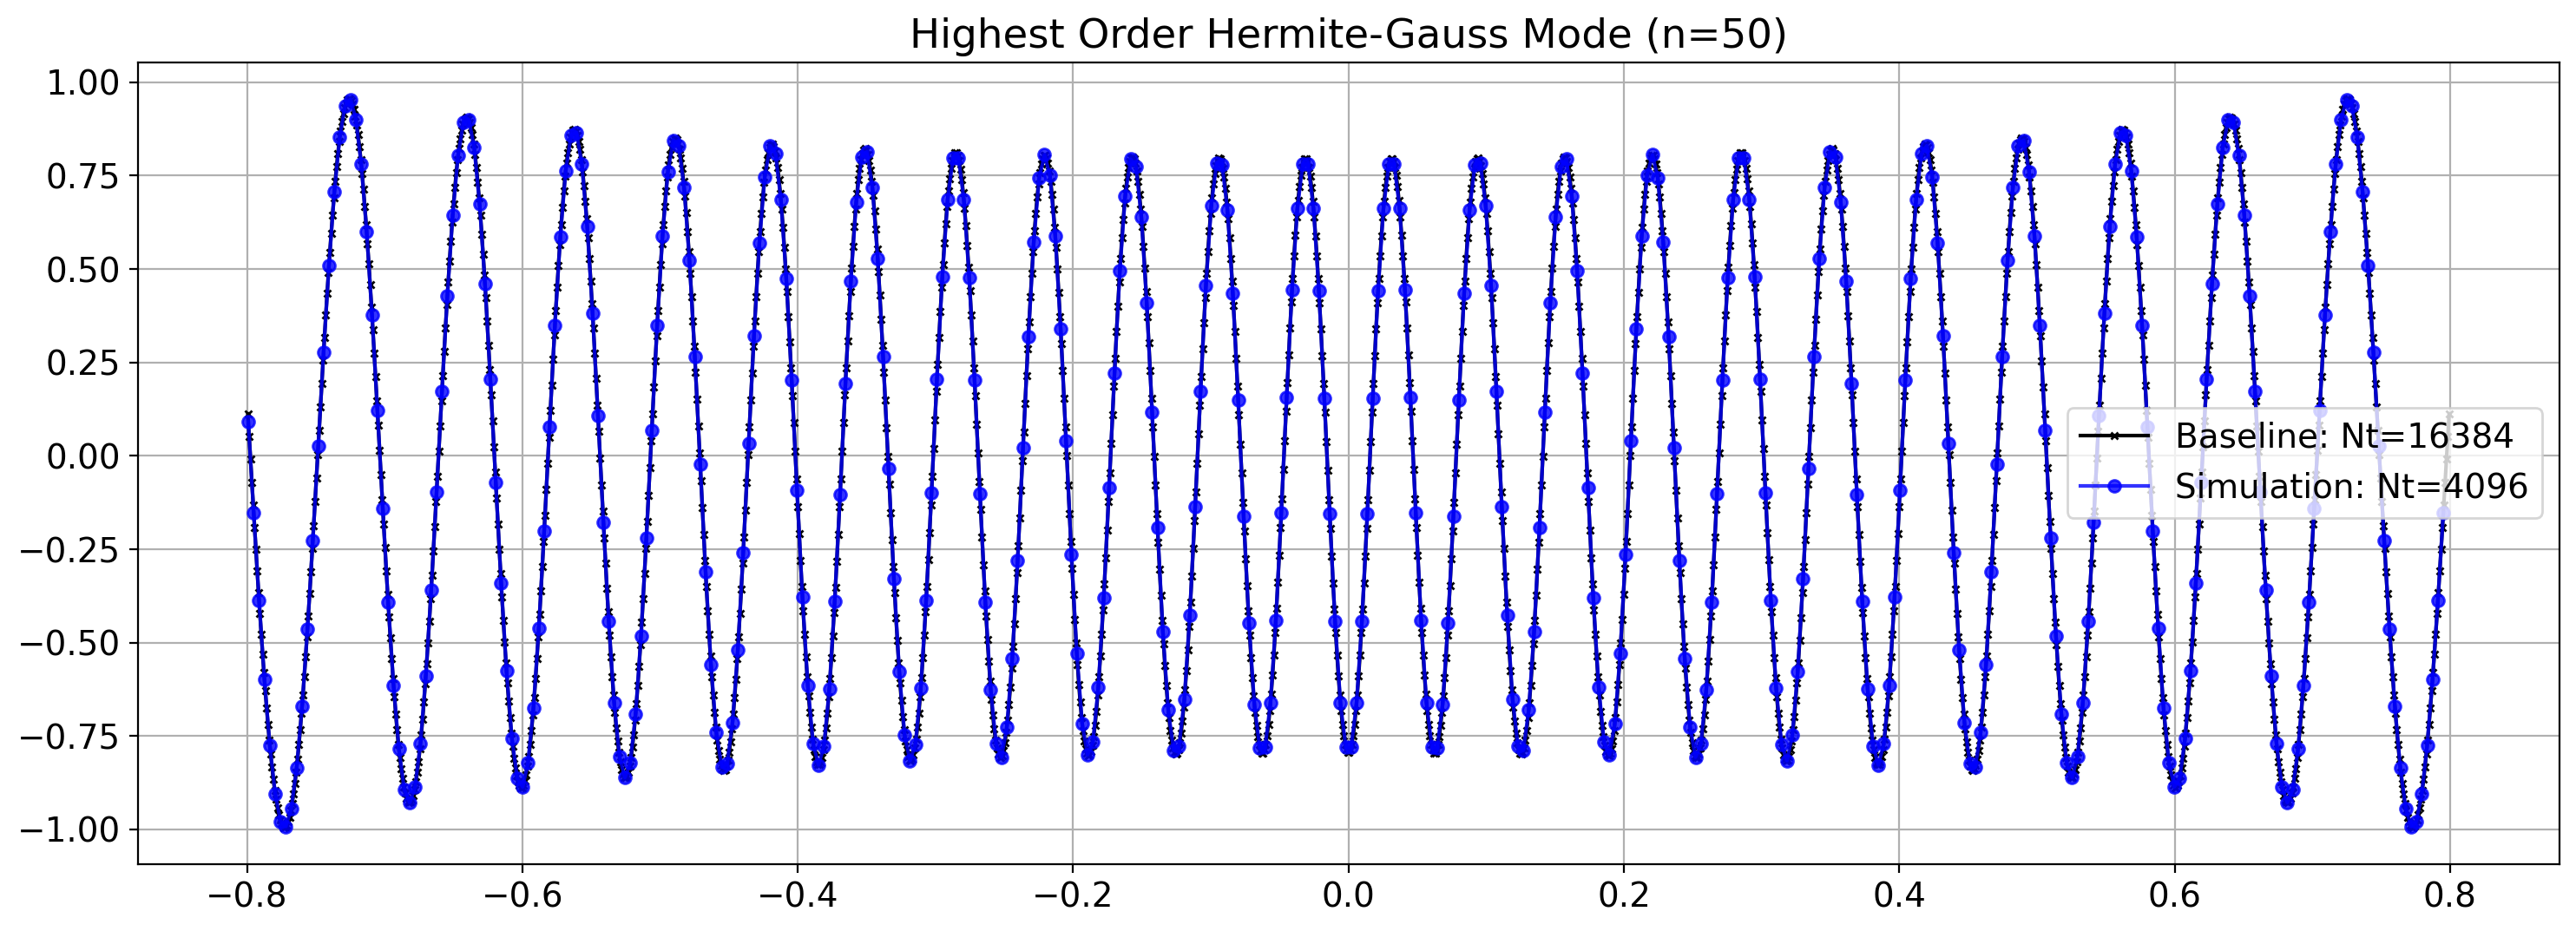

In [26]:
# Get the pulse in the time domain for the highest order HG basis mode
mode_index = 50 #! main parameter
pulse = hg_basis[mode_index]
pulse_high = hg_basis_high[mode_index]

# Show only the middle 40% of the pulse, i.e. exclude first 30% and last 30%
center_frac = 0.1
# pulse
Nt_center = int(Nt * center_frac)
start = int((Nt - Nt_center) / 2)
end = start + Nt_center
# pulse high
Nt_center_high = int(Nt_high * center_frac)
start_high = int((Nt_high - Nt_center_high) / 2)
end_high = start_high + Nt_center_high

fig, ax = plt.subplots(figsize=(18, 6), dpi=200)
ax.plot(t_high[start_high:end_high], pulse_high[start_high:end_high], marker='x', markersize=3, color='k', label = f"Baseline: Nt={Nt_high}")
ax.plot(t[start:end], pulse[start:end], color='blue', marker='o', markersize=5, label=f"Simulation: Nt={Nt}", alpha=0.8)
ax.set_title(f"Highest Order Hermite-Gauss Mode (n={mode_index})")
ax.legend()
ax.grid(True)

### Testing Evolution
Goal: Test actual evolution of mode within the simulation and whether or not aliasing/artefacts take place.

In [27]:
# Show only the middle 40% of the pulse, i.e. exclude first 30% and last 30%
def plot_mode(pulse_high, step):
    center_frac = 0.3
    Nt_center_high = int(Nt_high * center_frac)
    start_high = int((Nt_high - Nt_center_high) / 2)
    end_high = start_high + Nt_center_high

    fig, ax = plt.subplots(figsize=(18, 6), dpi=200)
    ax.plot(t_high[start_high:end_high], pulse_high[start_high:end_high], marker='x', markersize=3, color='k')
    ax.set_title(f"Highest Order Hermite-Gauss Mode (n={mode_index}) at step {step}.")
    ax.grid(True)
    plt.show()



def test_mode(A0_j, A0_k, plot_period, plot_end, dz, Nz, beta2_j, beta2_k, gamma_j, gamma_k, Lt, strangsplitting = True): # A_j = weak, A_k = strong
    """Implement the Split-Step Fourier Method with XPM using PyTorch."""
    A_j = A0_j.clone()
    A_k = A0_k.clone()
    Nt = len(A_j)
    dt = Lt / Nt
    A_j_evolution = torch.zeros((Nt, Nz+1), dtype=torch.complex64, device=A0_j.device)
    A_k_evolution = torch.zeros((Nt, Nz+1), dtype=torch.complex64, device=A0_k.device)
    A_j_evolution[:, 0] = A0_j  # Set first column of A_j_evolution to be the initial pulse
    A_k_evolution[:, 0] = A0_k  # Set first column of A_k_evolution to be the initial pulse

    for i in range(Nz):
        # we want to preserve symmetry in both of the waves - always use the wave at i-th step to go to i+1-th step ? is this that important?
        _A_j = A_j.clone() 
        _A_k = A_k.clone()
        
        if strangsplitting:
            A_j = nonlinear_operator_xpm(gamma_j, _A_j, _A_k, dz/2)  # Apply XPM nonlinear operator
            A_j = dispersion_operator(A_j, beta2_j, Nt, dt, dz)  # Apply dispersion operator
            A_j = nonlinear_operator_xpm(gamma_j, A_j, _A_k, dz/2)  # Apply XPM nonlinear operator
            
            A_k = nonlinear_operator_xpm(gamma_k, _A_k, _A_j, dz/2)  # Apply XPM nonlinear operator
            A_k = dispersion_operator(A_k, beta2_k, Nt, dt, dz)  # Apply dispersion operator
            A_k = nonlinear_operator_xpm(gamma_k, A_k, _A_j, dz/2)  # Apply XPM nonlinear operator
            
            A_j_evolution[:, i+1] = A_j
            A_k_evolution[:, i+1] = A_k
            
        else:
            # for weak wave j
            A_j = nonlinear_operator_xpm(gamma_j, _A_j, _A_k, dz)  # Apply XPM nonlinear operator
            A_j = dispersion_operator(A_j, beta2_j, Nt, dt, dz)  # Apply dispersion operator
            A_j_evolution[:, i+1] = A_j
            
            # for strong wave k
            A_k = nonlinear_operator_xpm(gamma_k, _A_k, _A_j, dz)  # Apply XPM nonlinear operator
            A_k = dispersion_operator(A_k, beta2_k, Nt, dt, dz)  # Apply dispersion operator
            A_k_evolution[:, i+1] = A_k
            
        # plotting
        if i % plot_period == 0 and i <= plot_end: # plot first few snapshots
            plot_mode(A_k, i)
        elif i == Nz-1:
            plot_mode(A_k, i) # plot last snapshot
            
    return A_j_evolution, A_k_evolution

0.3162277660168379


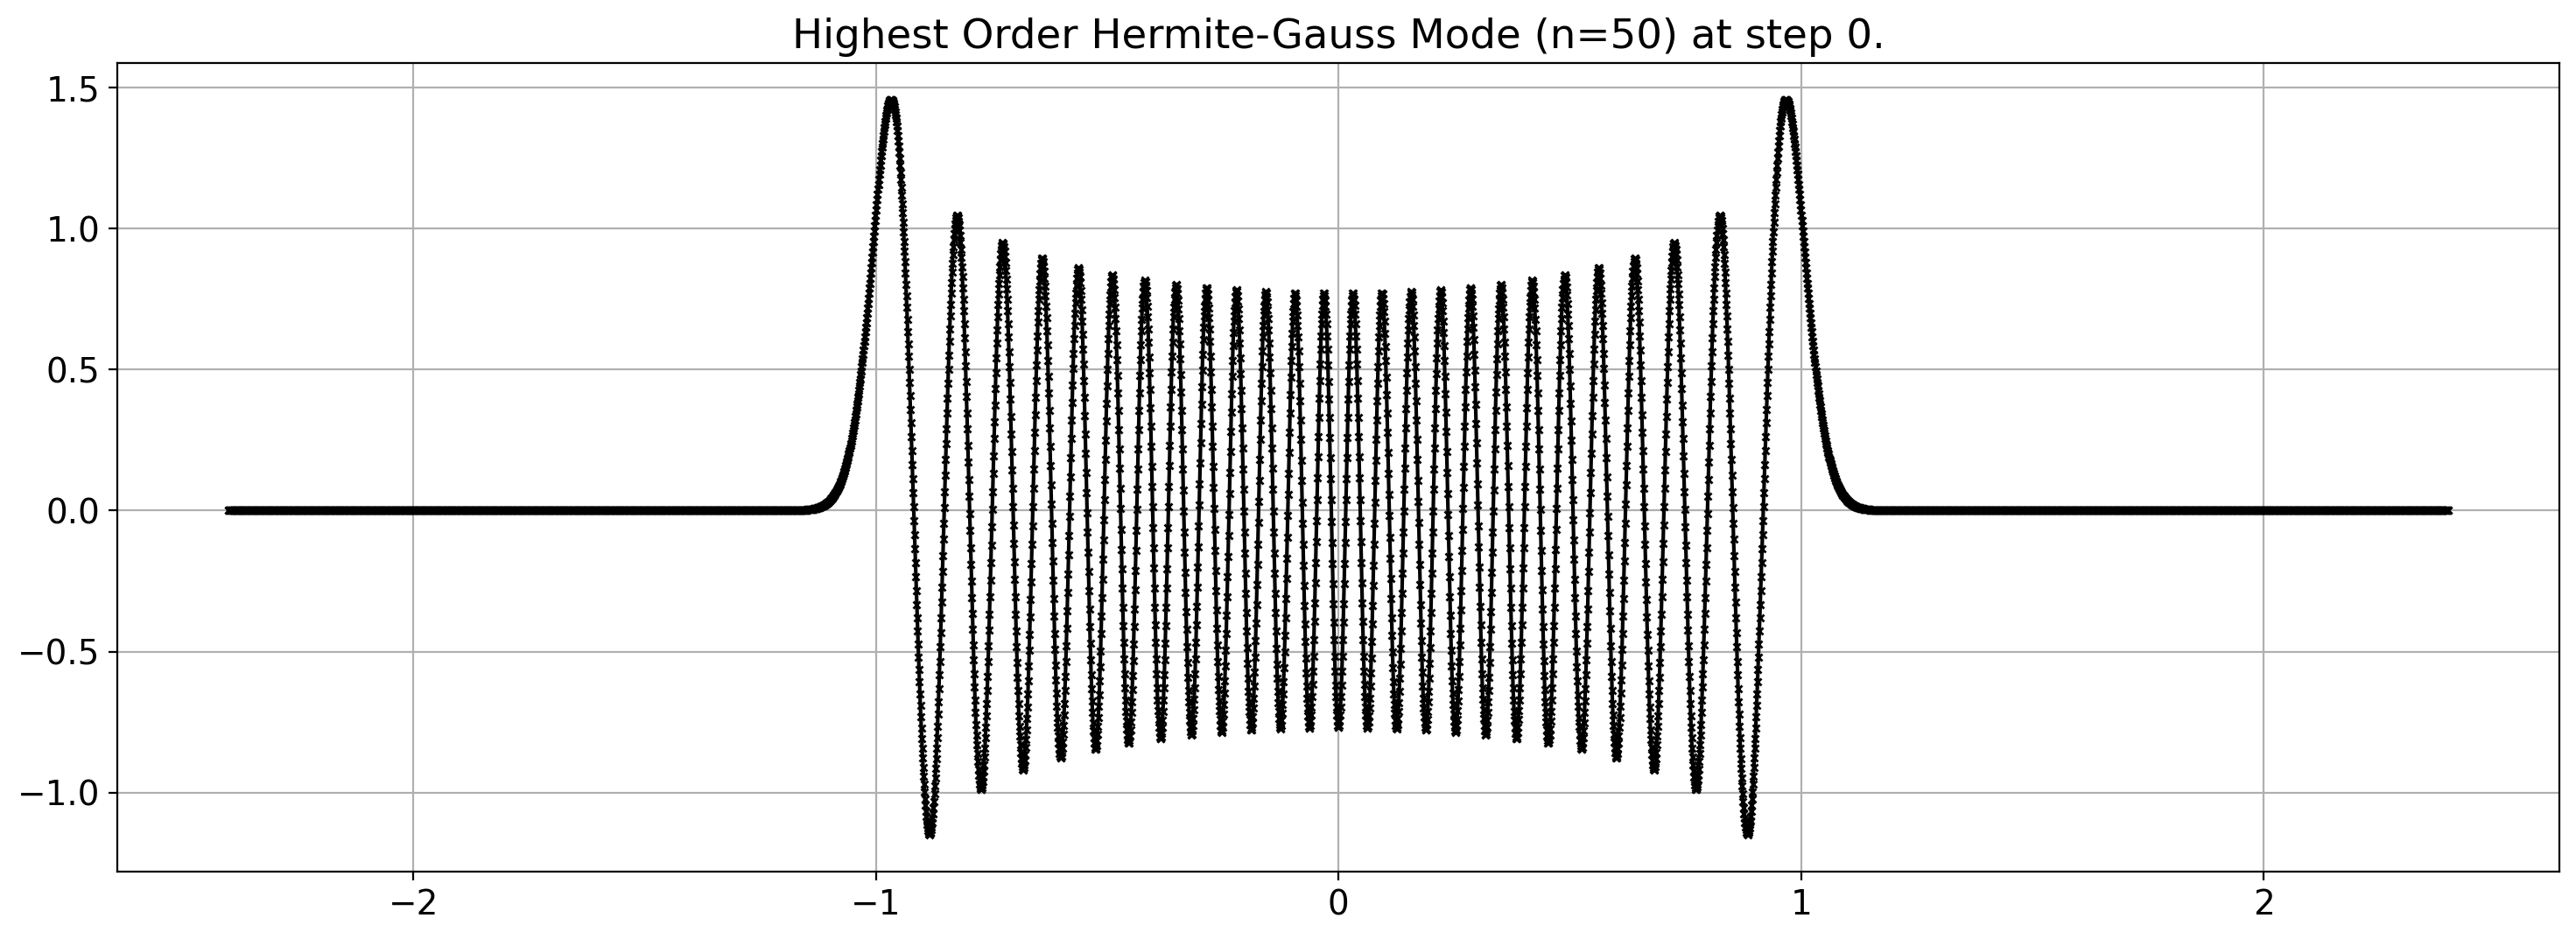

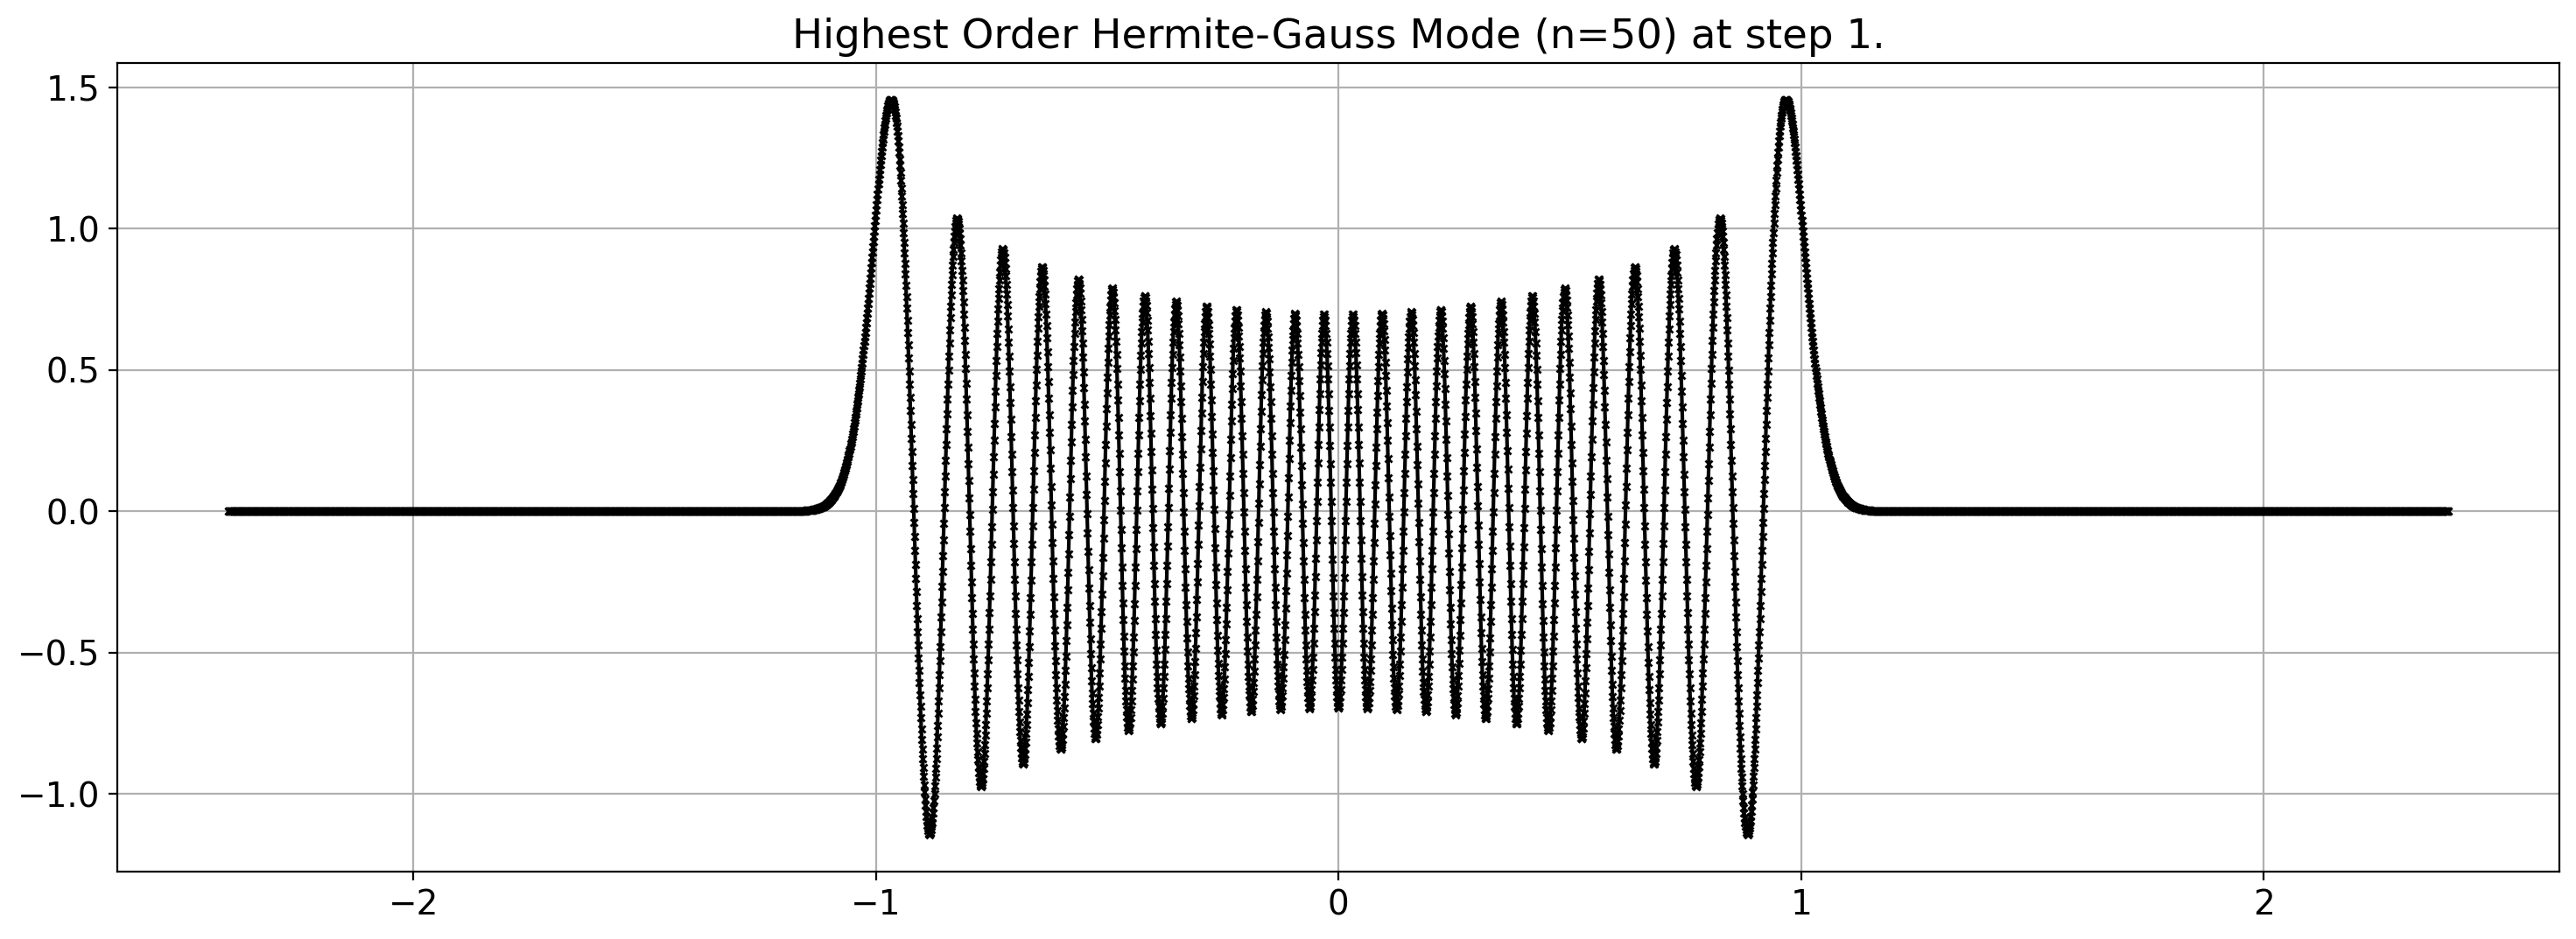

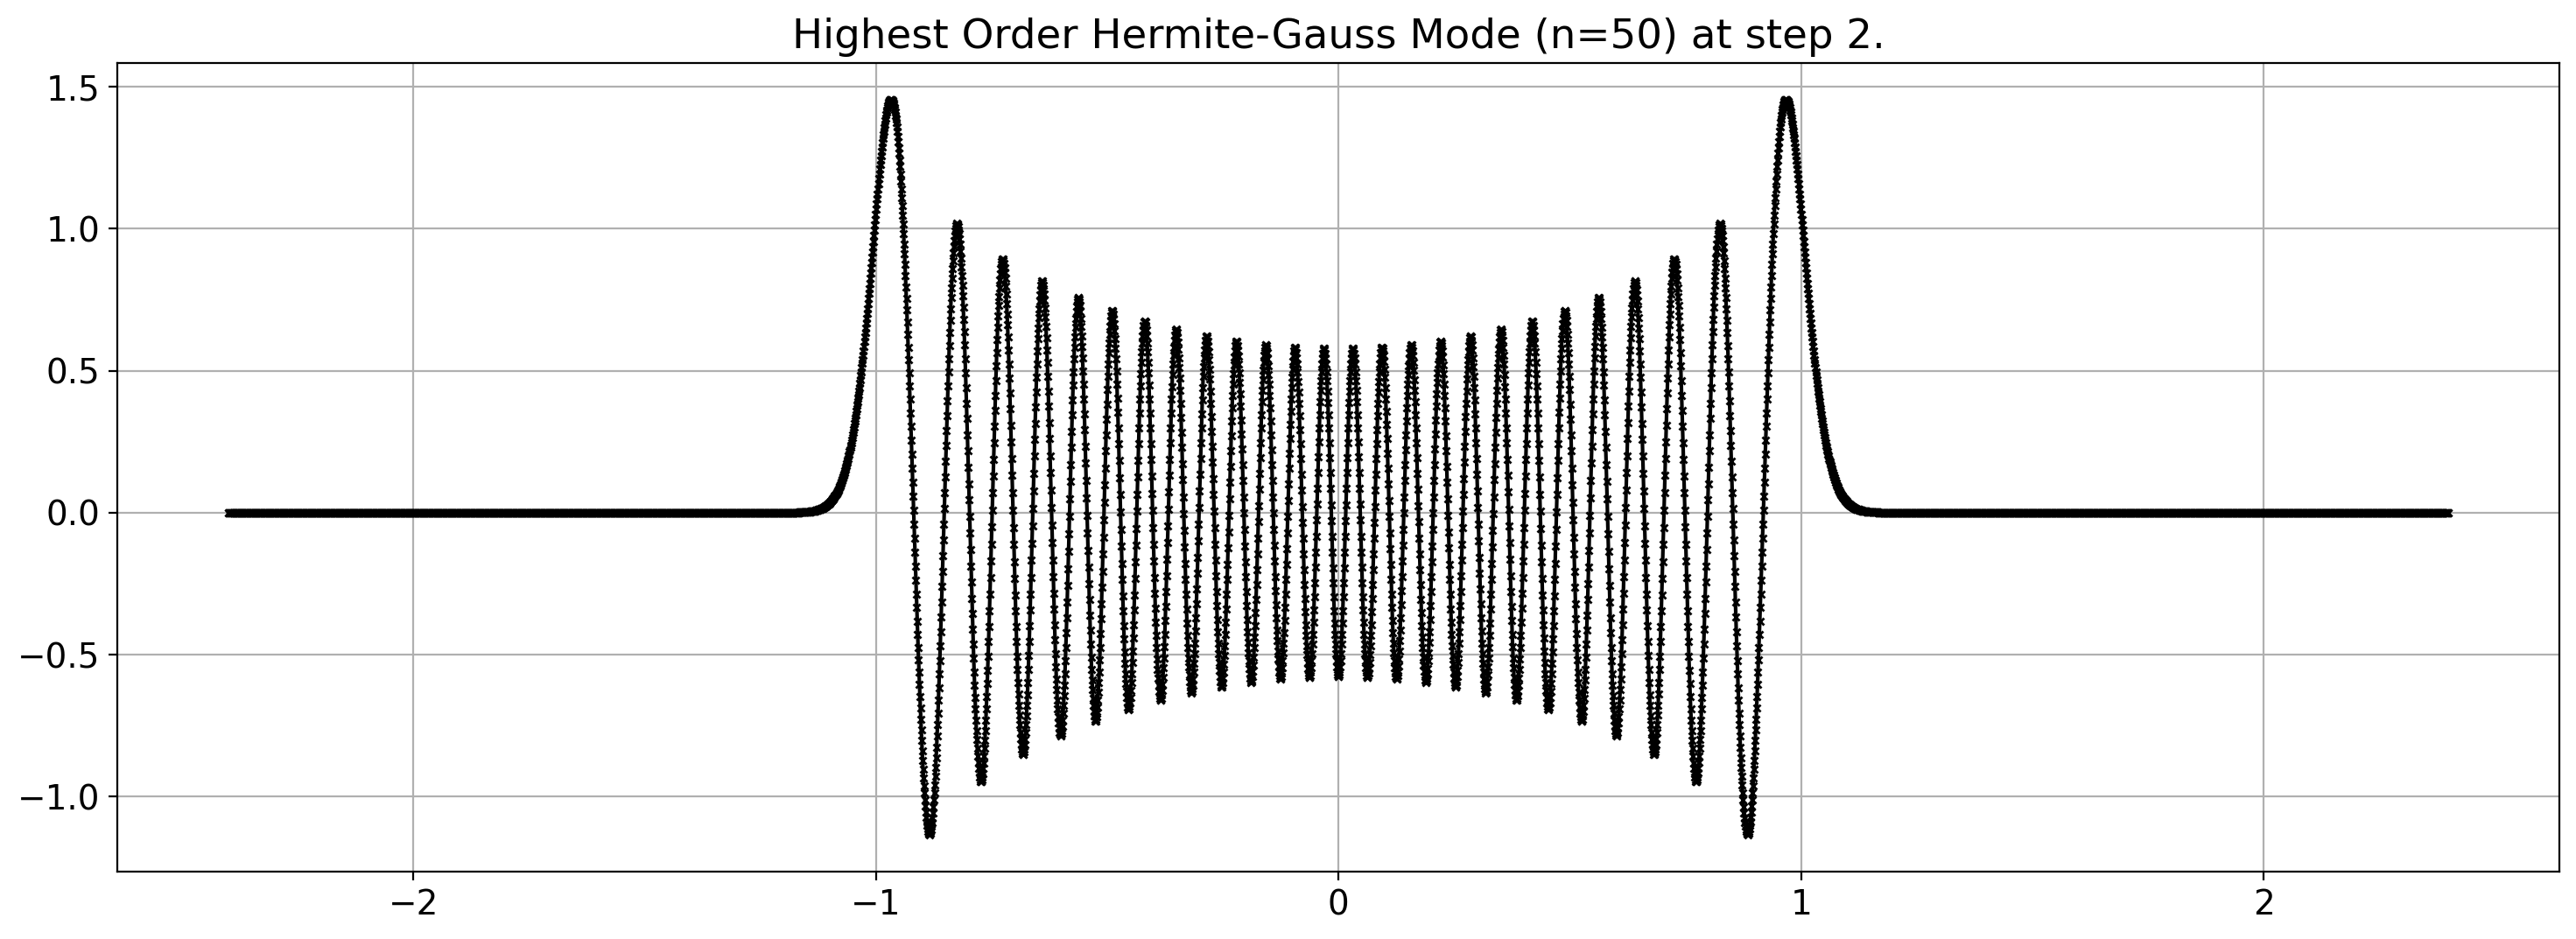

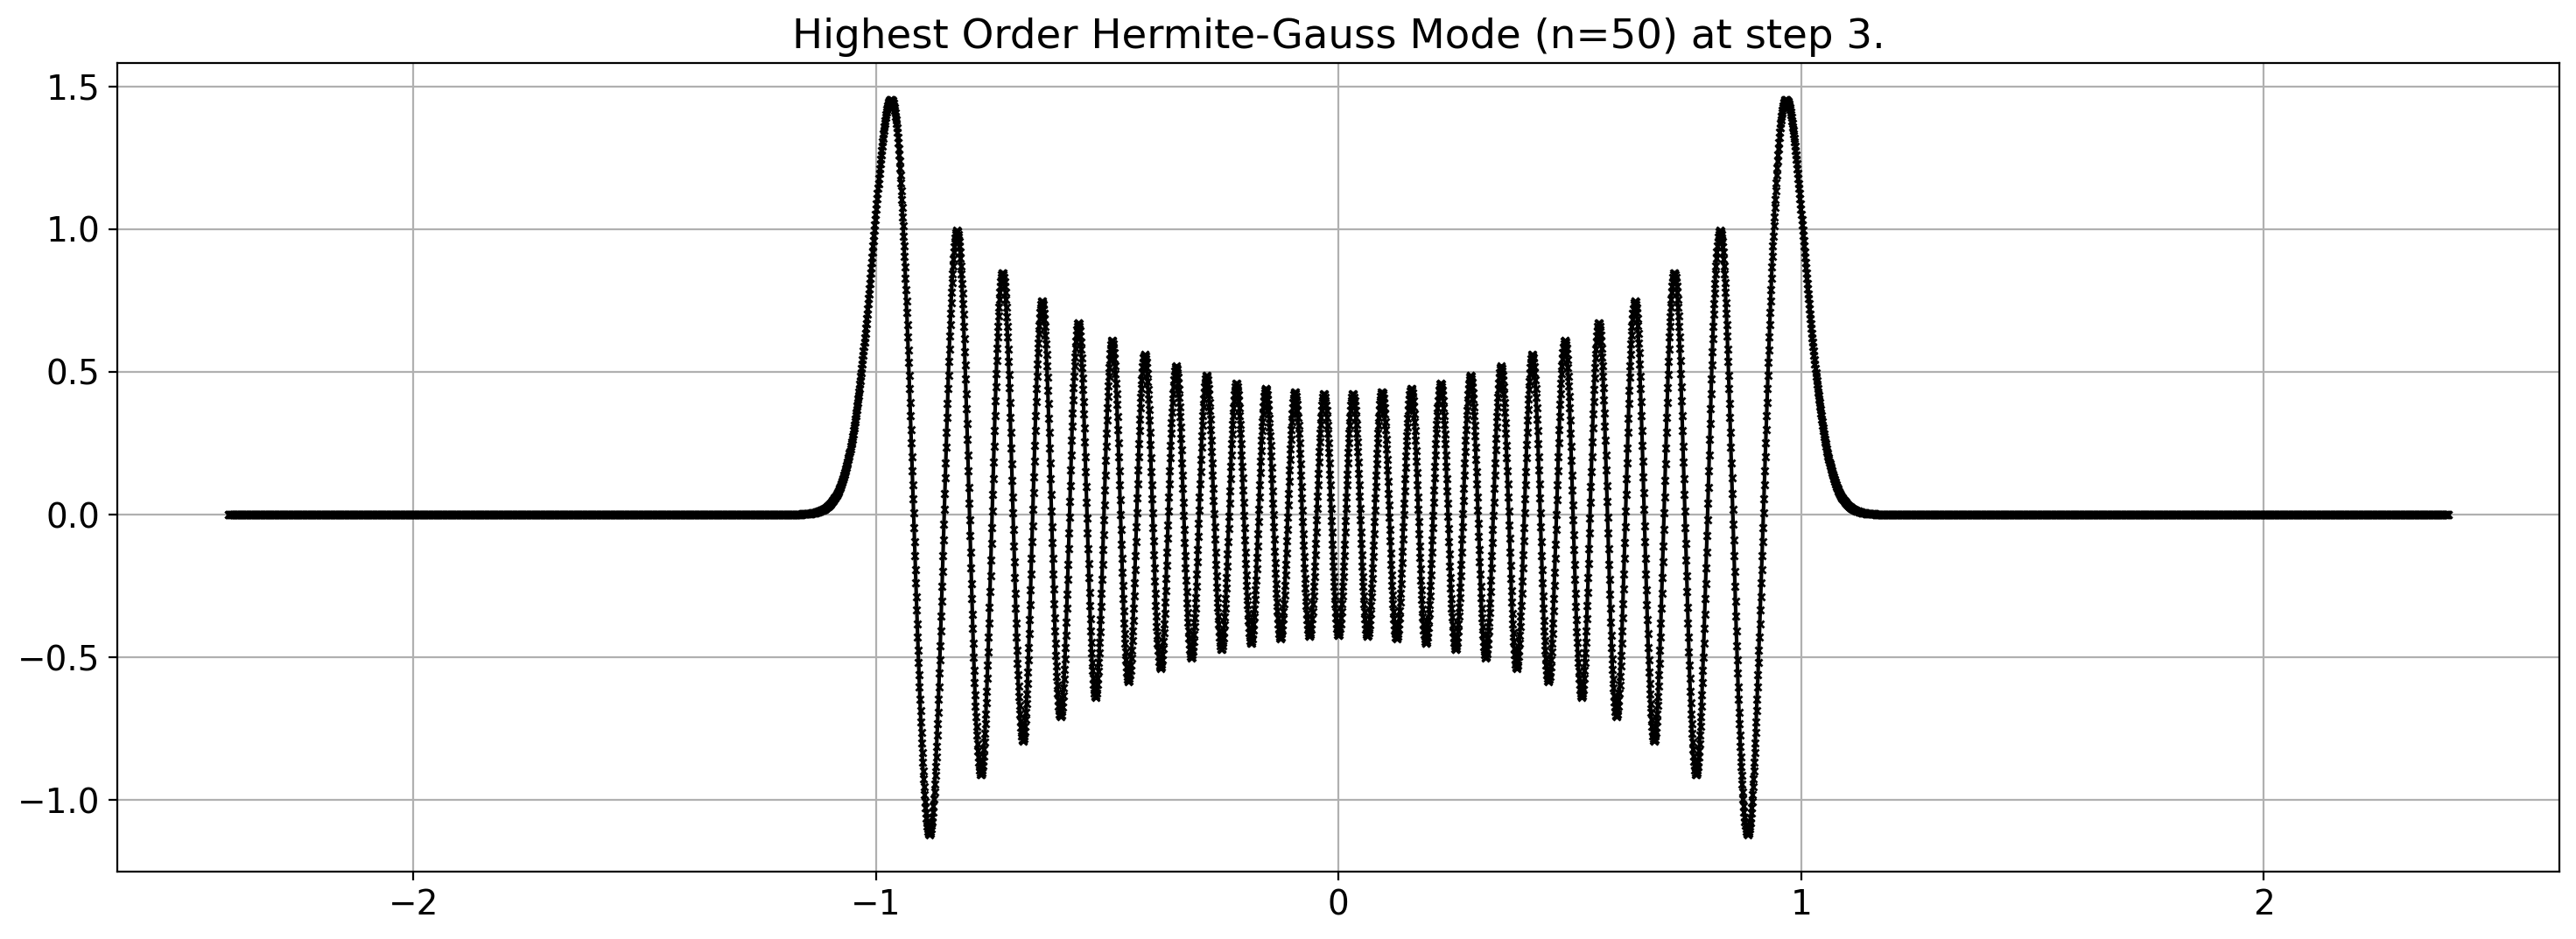

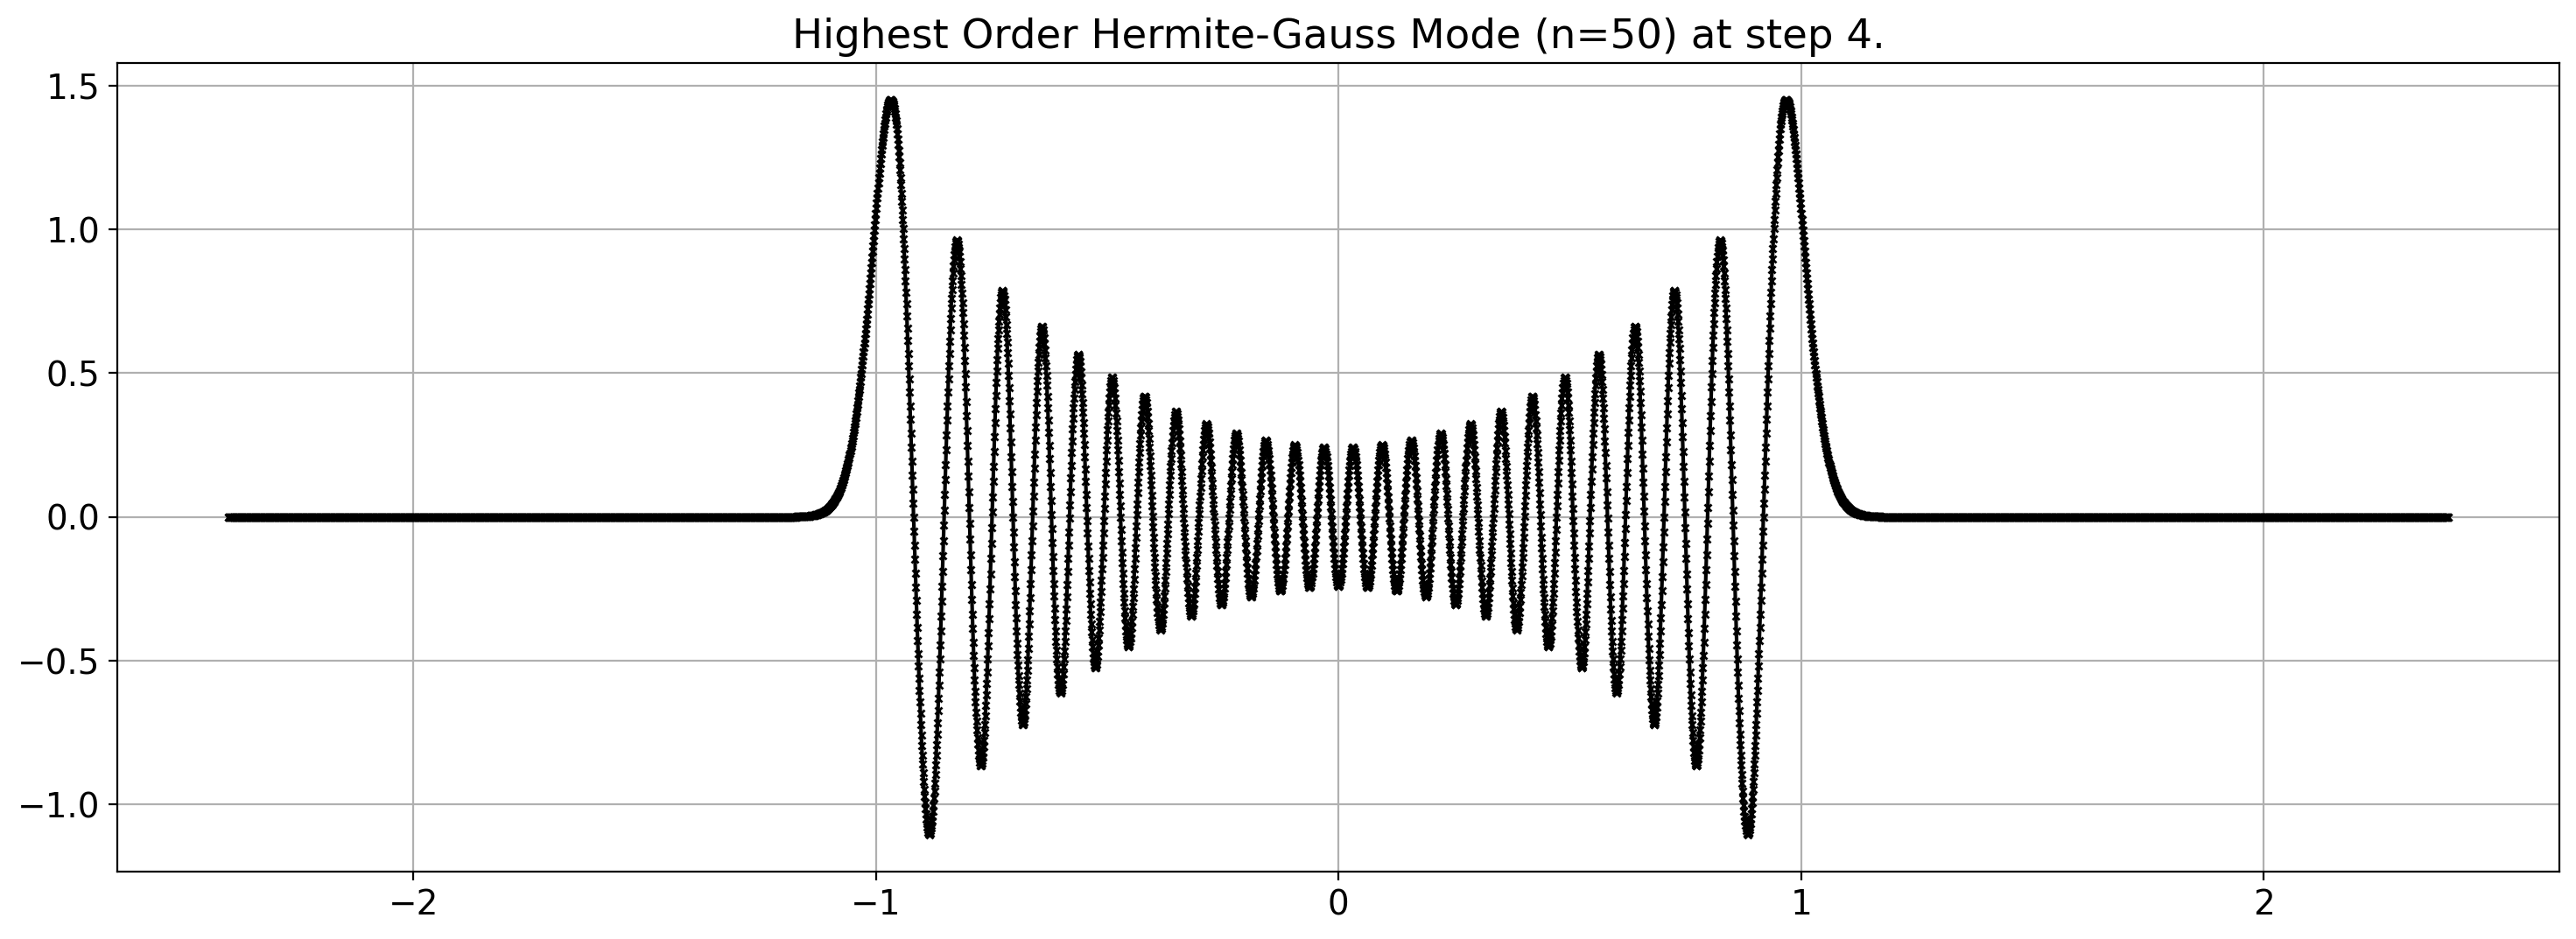

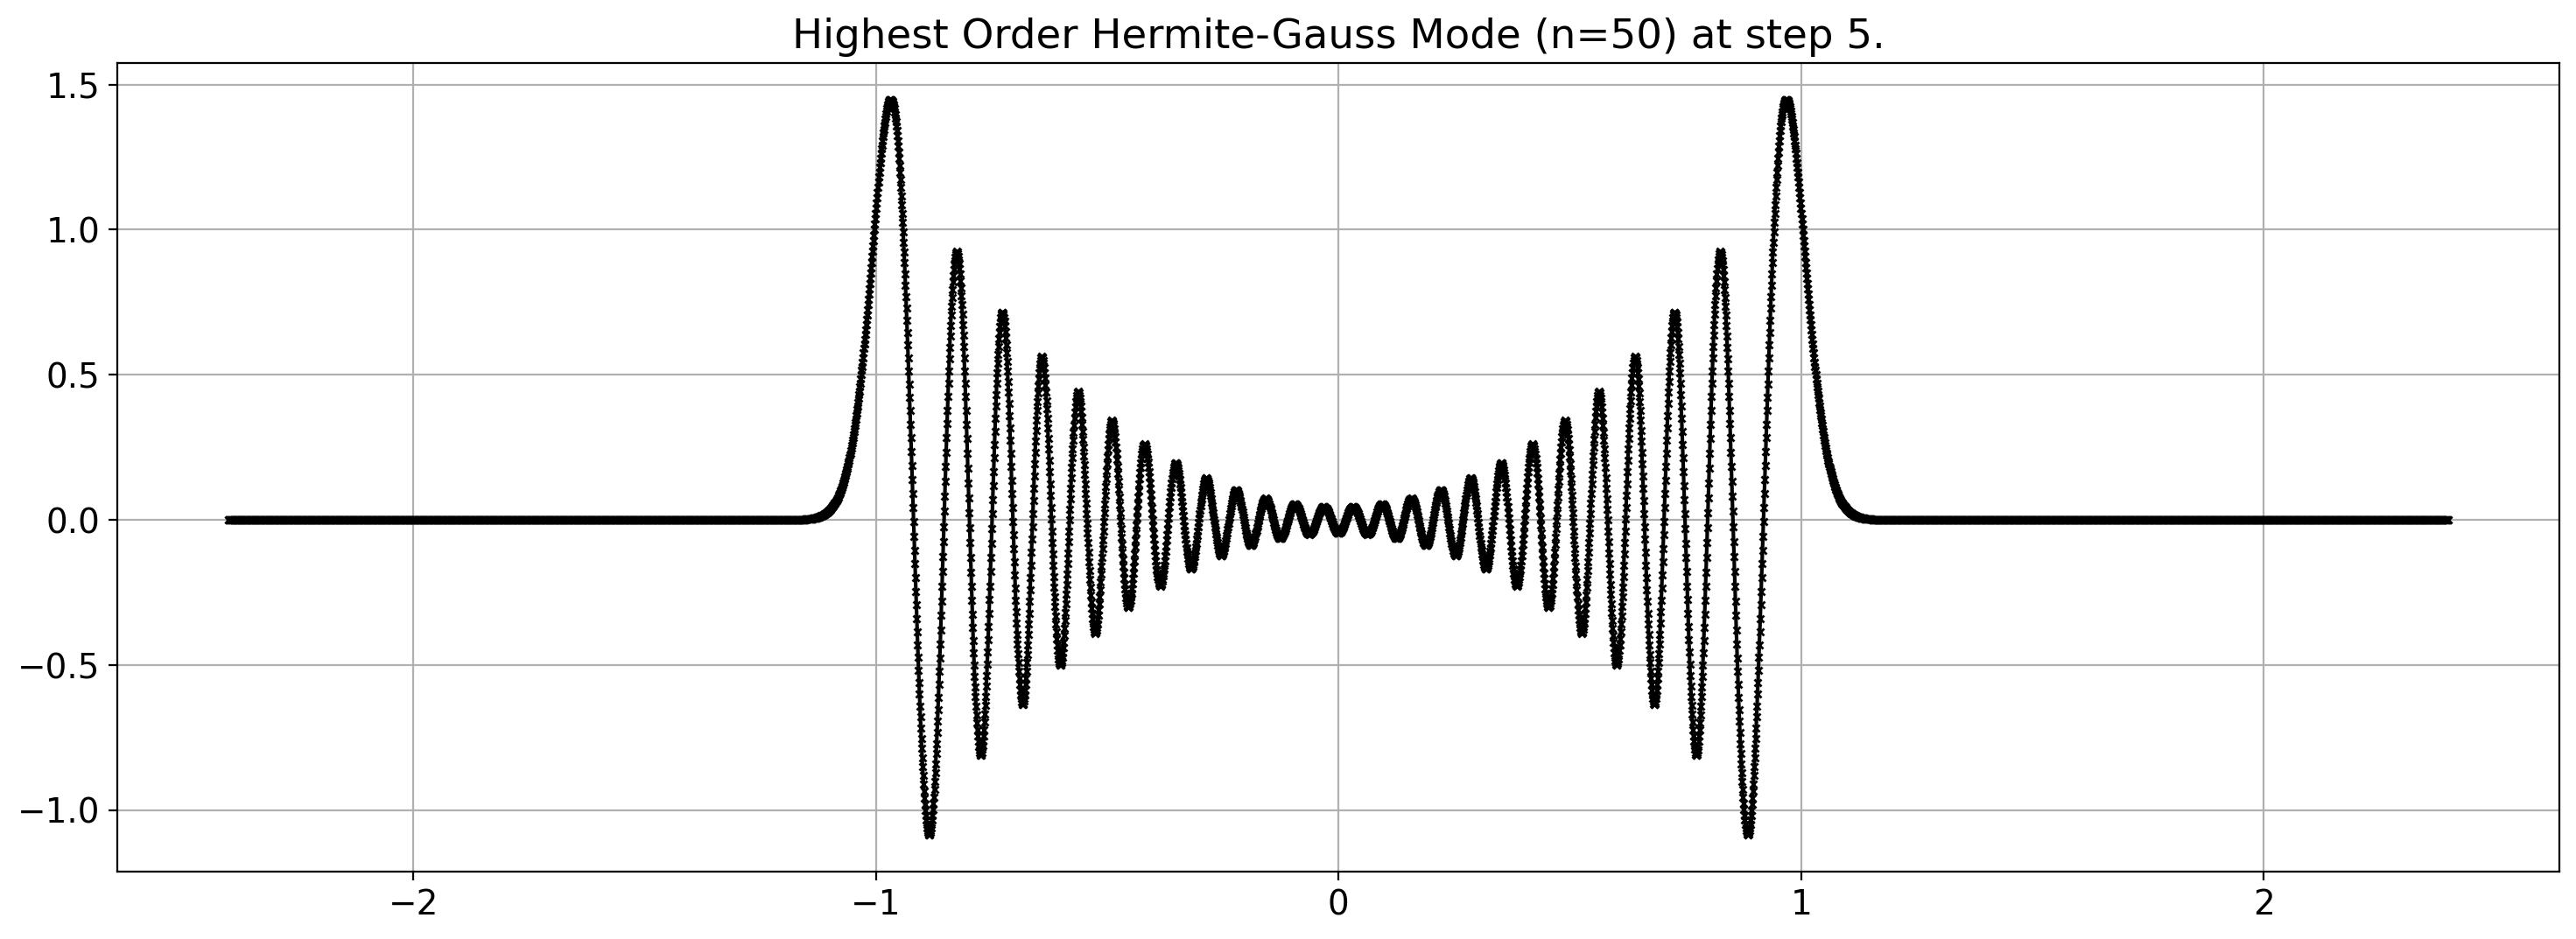

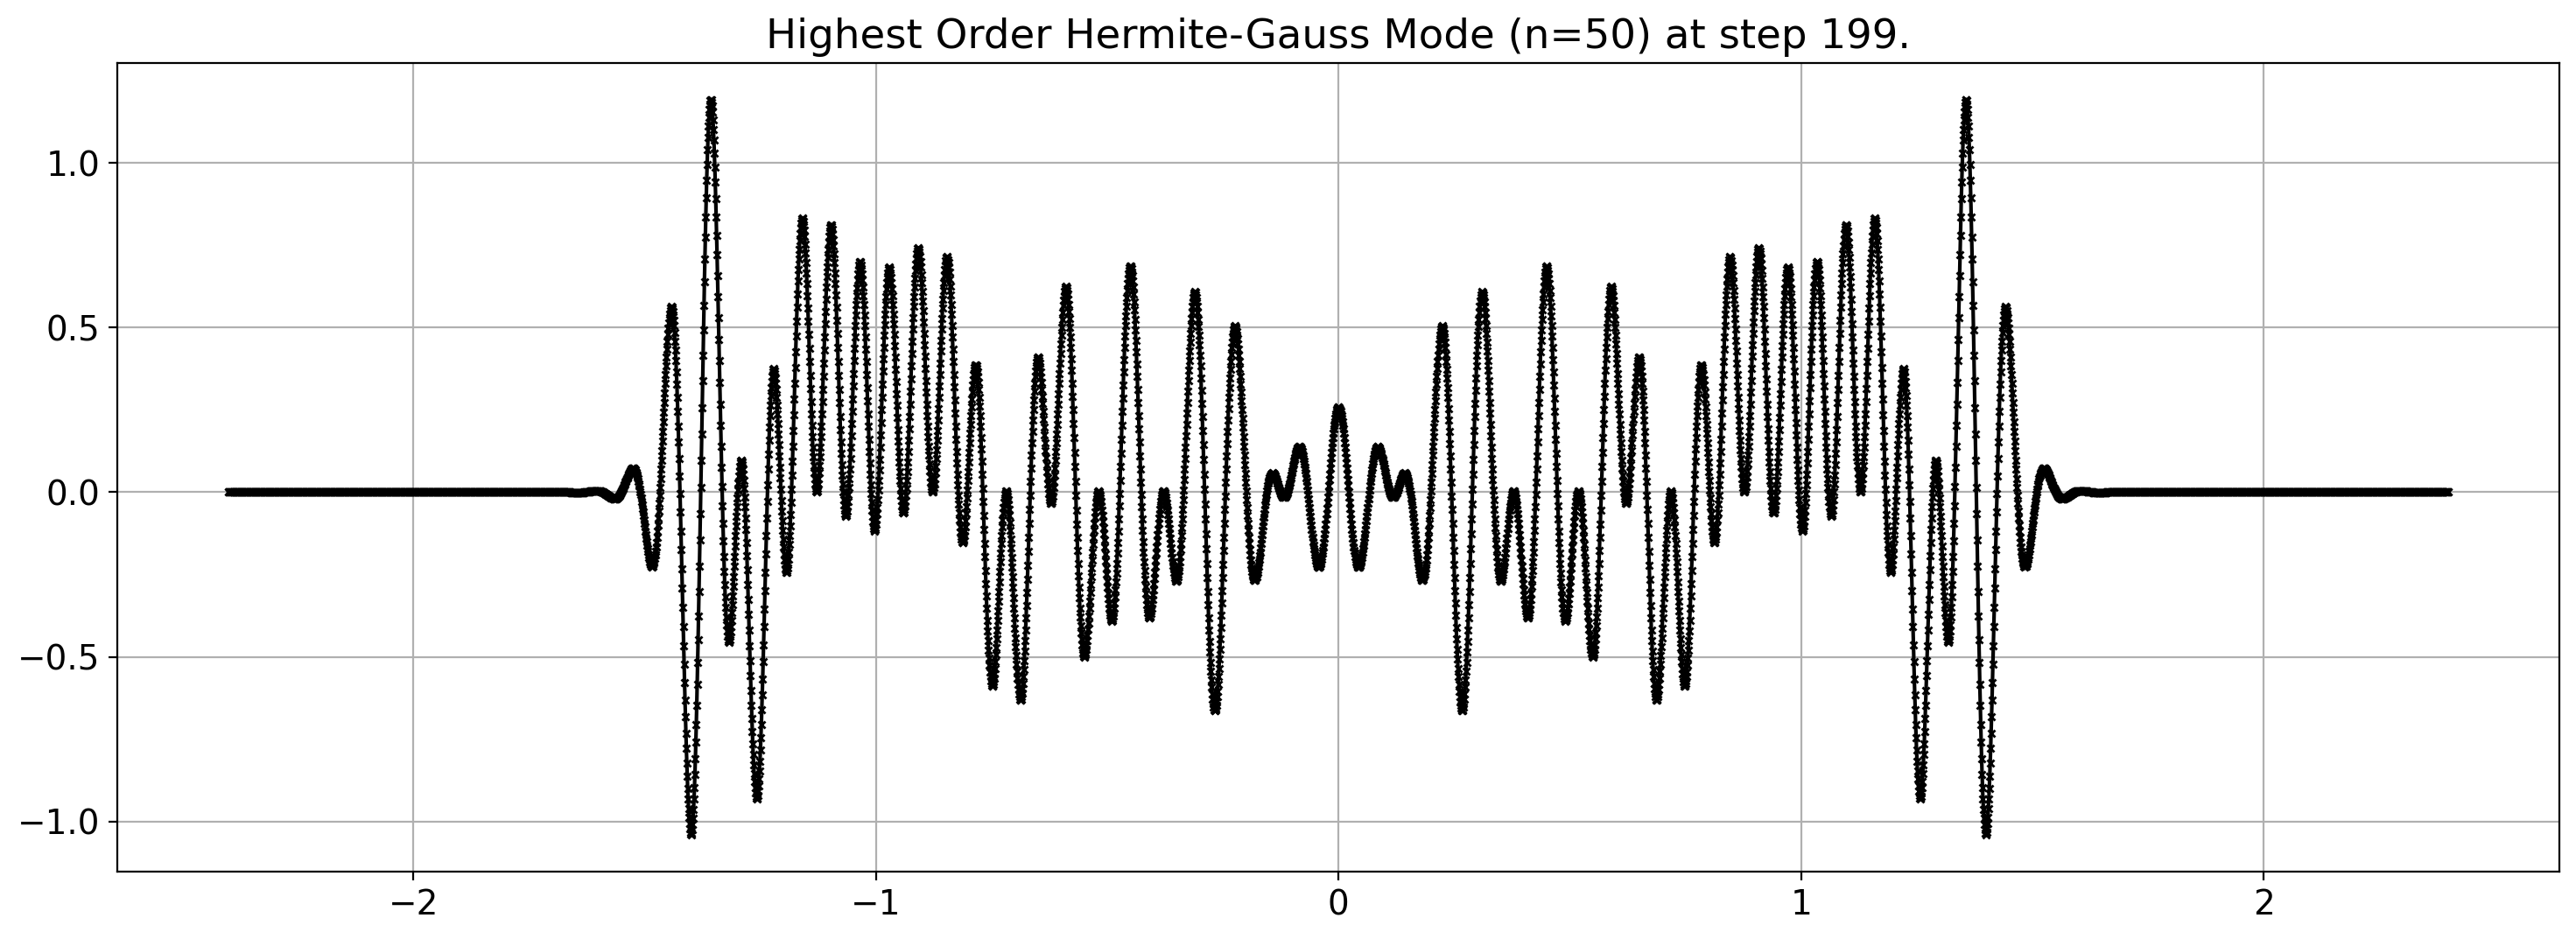

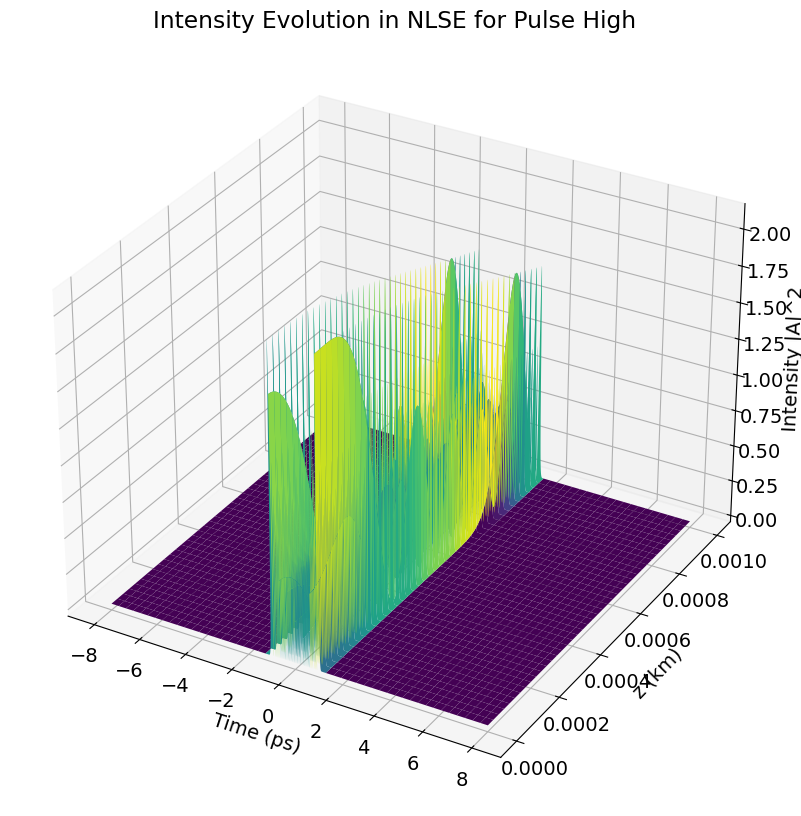

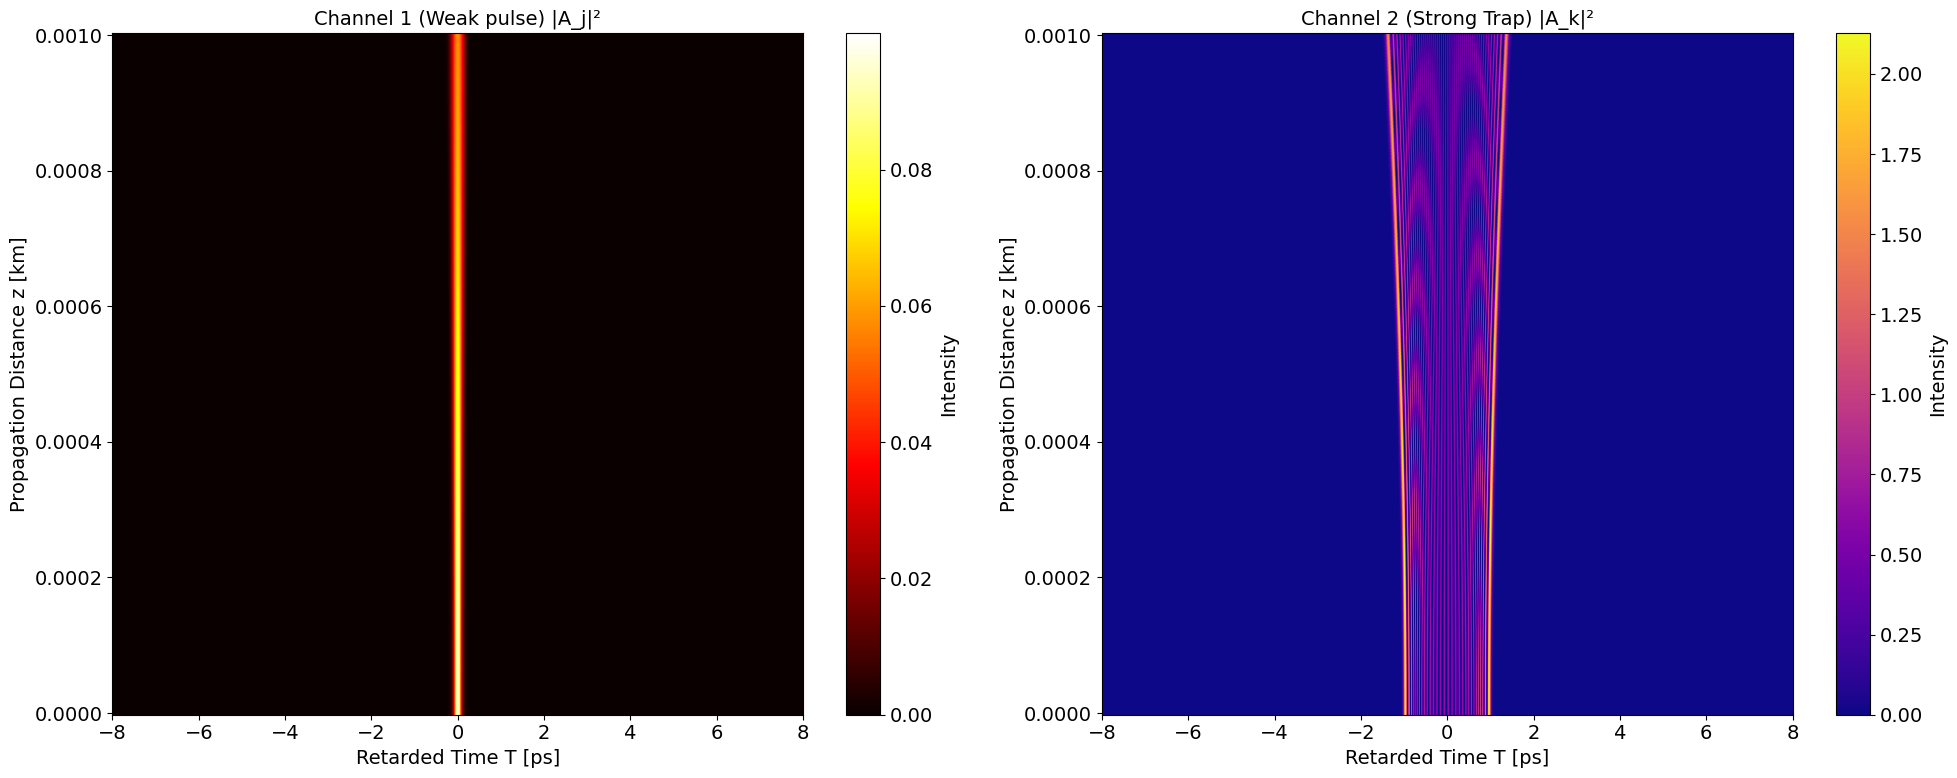

In [28]:
# dummy pulse
#null_pulse = torch.zeros_like(pulse) #* uncomment if want to use null pulse
weak = weak_soliton(t_high, beta2_k, beta2_j, gamma_j, gamma_k, tau, amplitude_ratio=100)

null_evolution, pulse_evolution = test_mode(weak, pulse_high, 1, 5, dz, Nz, beta2_j, beta2_k, gamma_j, gamma_k, Lt)

plot_intensity_evolution(pulse_evolution, t_high, Lz, Nz, wave_name='Pulse High')
plot_cowave_evolution(null_evolution.detach().clone(), pulse_evolution.detach().clone(), t_high, Lz, Nz)
